# 🇭🇷 VEPRAD Croatian Speech — CTC Segmentation Pipeline

This notebook aligns VEPRAD audio recordings with their transcripts and splits them into short segments (words) ready for ASR.

---

### 📁 Expected folder structure
```
Croatian-Language-Ctc_Segmentation/
├── VEPRAD/
│   ├── audio_m/      ← male audio
│   │       ├─m01/ male wav audio inside
│   │       ├─m02/ ...
│   ├── audio_z/      ← female audio
│   │       ├─z01/ female wav adudio inside
│   │       ├─z02/ ...
│   └── transkripcije_m+z/   ← transcripts
│                ├─m01/ txt transcripts inside
│                ├─m02/
│                ├─z01/ ...
└── veprad_ctc_segmentation.ipynb  ← this notebook
```

In [ ]:
import torch
import numpy as np
import soundfile as sf
import ctc_segmentation
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from pathlib import Path
import json

c:\Users\Lukas\.julia\conda\3\lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
c:\Users\Lukas\.julia\conda\3\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
c:\Users\Lukas\.julia\conda\3\lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [ ]:
MODEL_ID = "classla/wav2vec2-xls-r-parlaspeech-hr"

processor = Wav2Vec2Processor.from_pretrained(MODEL_ID)
model = Wav2Vec2ForCTC.from_pretrained(MODEL_ID)
model.eval()


c:\Users\Lukas\.julia\conda\3\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Lukas\.julia\conda\3\lib\site-packages\huggingface_hub\file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lukas\.cache\huggingface\hub\models--classla--wav2vec2-xls-r-parlaspeech-hr. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as 

Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projec

Verify or adjust the symbol mapping below.
---

| Symbol in file | Croatian character |
|---|---|
| `{` | `š` |
| `^` | `ć` |
| `~` | `č` |
| ` | `ž` |
| `\\` | `đ` |

**If any of these are wrong, edit the `REPLACEMENTS` dict before continuing.**

In [85]:
import re

REPLACEMENTS = {
    '{' : 'š',
    '^e': 'će',
    '^c': 'č',
    '^C': 'Č',
    '^' : 'ć',
    '~' : 'č',
    '`' : 'ž',
}

def normalize(text: str) -> str:
    for old, new in REPLACEMENTS.items():
        text = text.replace(old, new)
    # Remove transcript special symbols like <sil>, <uzdah>, <smijeh>
    text = re.sub(r'<[^>]+>', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text.strip().lower()

In [86]:
import soundfile as sf
audio, sr = sf.read(next(Path("VEPRAD/audio_m").rglob("*.wav")))
if audio.ndim > 1:
    audio = audio.mean(axis=1)

inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
with torch.no_grad():
    logits = model(**inputs).logits

n_frames = logits.shape[1]
duration = len(audio) / 16000
real_index_duration = duration / n_frames

print(f"Audio Length:  {duration:.3f}s")
print(f"Number of Frames:   {n_frames}")
print(f"Frame Duration:  {real_index_duration:.6f}s")

Audio Length:  4.624s
Number of Frames:   230
Frame Duration:  0.020102s


In [97]:
import librosa

def segment_file(wav_path: Path, transcript: str):
    audio, sr = sf.read(wav_path)
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    inputs = processor(
        audio, sampling_rate=16000,
        return_tensors="pt", padding=False
    )
    with torch.no_grad():
        logits = model(**inputs).logits
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    log_probs_np = log_probs[0].numpy()

    vocab = processor.tokenizer.get_vocab()
    vocab_list = [None] * len(vocab)
    for char, idx in vocab.items():
        vocab_list[idx] = char

    config = ctc_segmentation.CtcSegmentationParameters()
    config.char_list = vocab_list
    
    # FIX: Set blank token ID to the model's pad token ID
    config.blank = processor.tokenizer.pad_token_id
    
    duration = len(audio) / 16000
    config.index_duration = duration / log_probs_np.shape[0]

    words = transcript.split()
    ground_truth_mat, utt_begin_indices = ctc_segmentation.prepare_text(config, words)
    timings, char_probs, _ = ctc_segmentation.ctc_segmentation(
        config, log_probs_np, ground_truth_mat
    )
    segments = ctc_segmentation.determine_utterance_segments(
        config, utt_begin_indices, char_probs, timings, words
    )

    return [
        {"text": word, "start": s[0], "end": s[1], "conf": s[2]}
        for word, s in zip(words, segments)
    ]

## File Segmentation

I used `for wav_path in sorted(audio_dir.rglob("*.wav"))[:10]:` to speed up testing on only 10 files, to use the full dataset remove `[:10]`.

In [ ]:
VEPRAD = Path("VEPRAD")
results = []
errors = []

for speaker_type in ["m", "z"]:
    audio_dir = VEPRAD / f"audio_{speaker_type}"
    for wav_path in sorted(audio_dir.rglob("*.wav"))[:10]: # <- limit to 10 files for testing, remove [:10] for full dataset
        speaker = wav_path.parent.name          # npr. "m01"
        txt_name = wav_path.stem + ".txt"
        txt_path = VEPRAD / "transkripcije_m+z" / speaker / txt_name

        if not txt_path.exists():
            errors.append(str(wav_path))
            continue

        raw = txt_path.read_text(encoding="utf-8", errors="replace")
        transcript = normalize(raw)

        try:
            segs = segment_file(wav_path, transcript)
            results.append({
                "file": str(wav_path),
                "speaker": speaker,
                "transcript": transcript,
                "segments": segs
            })
            print(f"✓ {wav_path.name}: {segs[0]['start']:.2f}s – {segs[0]['end']:.2f}s")
        except Exception as e:
            errors.append(f"{wav_path}: {e}")
            print(f"✗ {wav_path.name}: {e}")

✓ m01020105401.wav: 0.15s – 1.32s
✓ m01020105402.wav: 0.08s – 0.41s
✓ m01020205101.wav: 0.07s – 0.59s
✓ m01020205102.wav: 0.02s – 0.38s
✓ m01020205103.wav: 0.03s – 0.37s
✓ m01020205104.wav: 0.02s – 0.09s
✓ m01020205105.wav: 0.02s – 0.61s
✓ m01020205201.wav: 0.05s – 1.06s
✓ m01020205202.wav: 0.06s – 0.47s
✓ m01020205203.wav: 0.06s – 0.33s
✓ z01010103101.wav: 0.02s – 0.41s
✓ z01030402101.wav: 0.13s – 0.51s
✓ z01030402102.wav: 0.16s – 0.58s
✓ z01030402103.wav: 0.24s – 0.53s
✓ z01030402104.wav: 0.16s – 0.63s
✓ z01030402201.wav: 0.16s – 0.61s
✓ z01030402202.wav: 0.15s – 0.57s
✓ z01030402203.wav: 0.19s – 0.69s
✓ z01030602401.wav: 0.09s – 0.55s
✓ z01030602402.wav: 0.02s – 0.29s


In [99]:
# Save results to JSON
with open("segmentation_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f"\Done: {len(results)} ok, {len(errors)} errors")

\Done: 20 ok, 0 errors


Duration: 4.624s


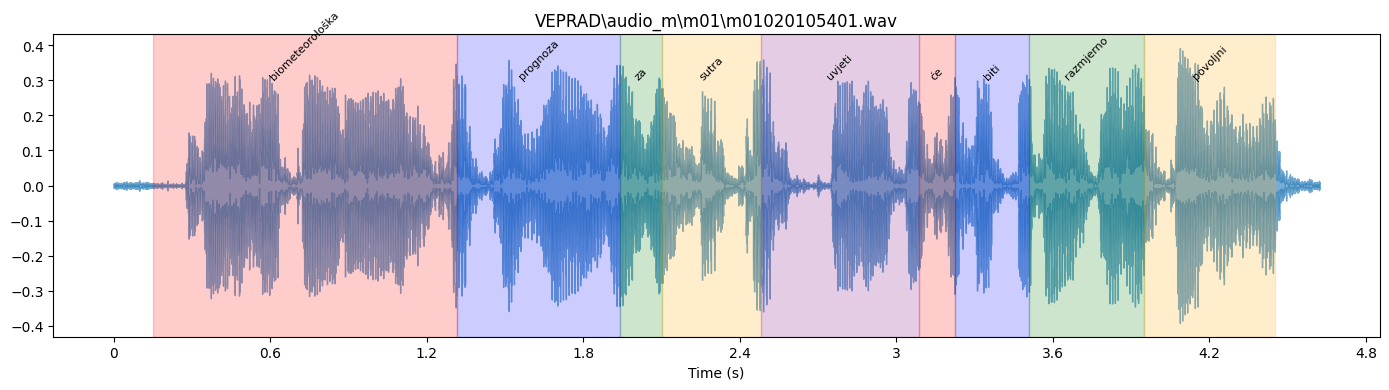


Word                   Start     End   Duration
------------------------------------------------
biometeorološka       0.151s  1.317s    1.166s
prognoza              1.317s  1.940s    0.623s
za                    1.940s  2.101s    0.161s
sutra                 2.101s  2.483s    0.382s
uvjeti                2.483s  3.086s    0.603s
će                    3.086s  3.226s    0.141s
biti                  3.226s  3.508s    0.281s
razmjerno             3.508s  3.950s    0.442s
povoljni              3.950s  4.453s    0.503s


In [100]:
import matplotlib.pyplot as plt
import librosa, librosa.display

def visualize(result: dict):
    audio, sr = sf.read(result["file"])
    fig, ax = plt.subplots(figsize=(14, 4))
    
    librosa.display.waveshow(audio, sr=sr, ax=ax, alpha=0.6)
    
    colours = ["red", "blue", "green", "orange", "purple"]
    for i, seg in enumerate(result["segments"]):
        col = colours[i % len(colours)]
        ax.axvspan(seg["start"], seg["end"], alpha=0.2, color=col)
        ax.text(
            (seg["start"] + seg["end"]) / 2, 0.85,
            seg["text"],  
            ha="center", fontsize=8, rotation=45,
            transform=ax.get_xaxis_transform()
        )
    
    ax.set_title(result["file"])
    ax.set_xlabel("Time (s)")
    plt.tight_layout()
    plt.savefig("segmentation_example.png", dpi=150)
    plt.show()

    # Output table
    print(f"\n{'Word':<20} {'Start':>7} {'End':>7} {'Duration':>10}")
    print("-" * 48)
    for seg in result["segments"]:
        dur = seg['end'] - seg['start']
        print(f"{seg['text']:<20} {seg['start']:>6.3f}s {seg['end']:>6.3f}s {dur:>8.3f}s")
    
info = sf.info(results[0]["file"])
duration = info.duration  # in seconds
print(f"Duration: {duration:.3f}s")

visualize(results[0])

In [ ]:
import soundfile as sf
from pathlib import Path

def cut_audio(result: dict, out_dir: Path = Path("cut")):
    # Cuts the audio into segments based on the CTC segmentation results.
    out_dir.mkdir(exist_ok=True)
    
    wav_path = Path(result["file"])
    audio, sr = sf.read(wav_path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    
    # Subfolder for each audio file, e.g. "cut/m01_01_biometeoroloska/"
    wav_dir = out_dir / wav_path.stem
    wav_dir.mkdir(exist_ok=True)
    
    for i, seg in enumerate(result["segments"]):
        start_sample = int(seg["start"] * sr)
        end_sample   = int(seg["end"] * sr)
        isjecak = audio[start_sample:end_sample]
        
        # Name: 01_biometeorološka.wav, 02_prognoza.wav, ...
        # zfill(2) → always 2 digits for proper sorting
        ime = f"{str(i+1).zfill(2)}_{seg['text']}.wav"
        out_path = wav_dir / ime
        sf.write(out_path, isjecak, sr)
        
        trajanje = seg['end'] - seg['start']
        print(f"  ✓ {ime}  ({trajanje:.3f}s)")
    
    print(f"\n📁 Cuts saved to: {wav_dir}/")
    return wav_dir

# Start cutting for the 10th result (index 9)
cut_audio(results[9])

  ✓ 01_biometeorološka.wav  (1.166s)
  ✓ 02_prognoza.wav  (0.623s)
  ✓ 03_za.wav  (0.161s)
  ✓ 04_sutra.wav  (0.382s)
  ✓ 05_uvjeti.wav  (0.603s)
  ✓ 06_će.wav  (0.141s)
  ✓ 07_biti.wav  (0.281s)
  ✓ 08_razmjerno.wav  (0.442s)
  ✓ 09_povoljni.wav  (0.503s)

📁 Cuts saved to: cut\m01020105401/


WindowsPath('cut/m01020105401')

Number of segmented words: 232
From a total of 20 recordings


1. Success Rate (based on confidence)
   High  (conf > -1.0):     158  (68.1%)
   Mid (-2.0 to -1.0):     41  (17.7%)
   Low   (conf < -2.0):      33  (14.2%)
   Average confidence:      -1.094

2. TALKING SPEED (words/second)
   Male    : mean=2.63  median=2.62  std=0.49
   Female  : mean=2.57  median=2.57  std=0.32

3. CORRELATION: word length ↔ duration
   Pearson r = 0.875
   (>0.7 = strong positive correlation = segmentation makes sense)

4. AVERAGE DURATION PER CHARACTER
   Entire dataset: 80.2 ms/character
   Male    :    74.7 ms/character
   Female  :    84.2 ms/character


C:\Users\Lukas\AppData\Local\Temp\ipykernel_16232\1138842643.py:97: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([by_speakers["m"], by_speakers["z"]],


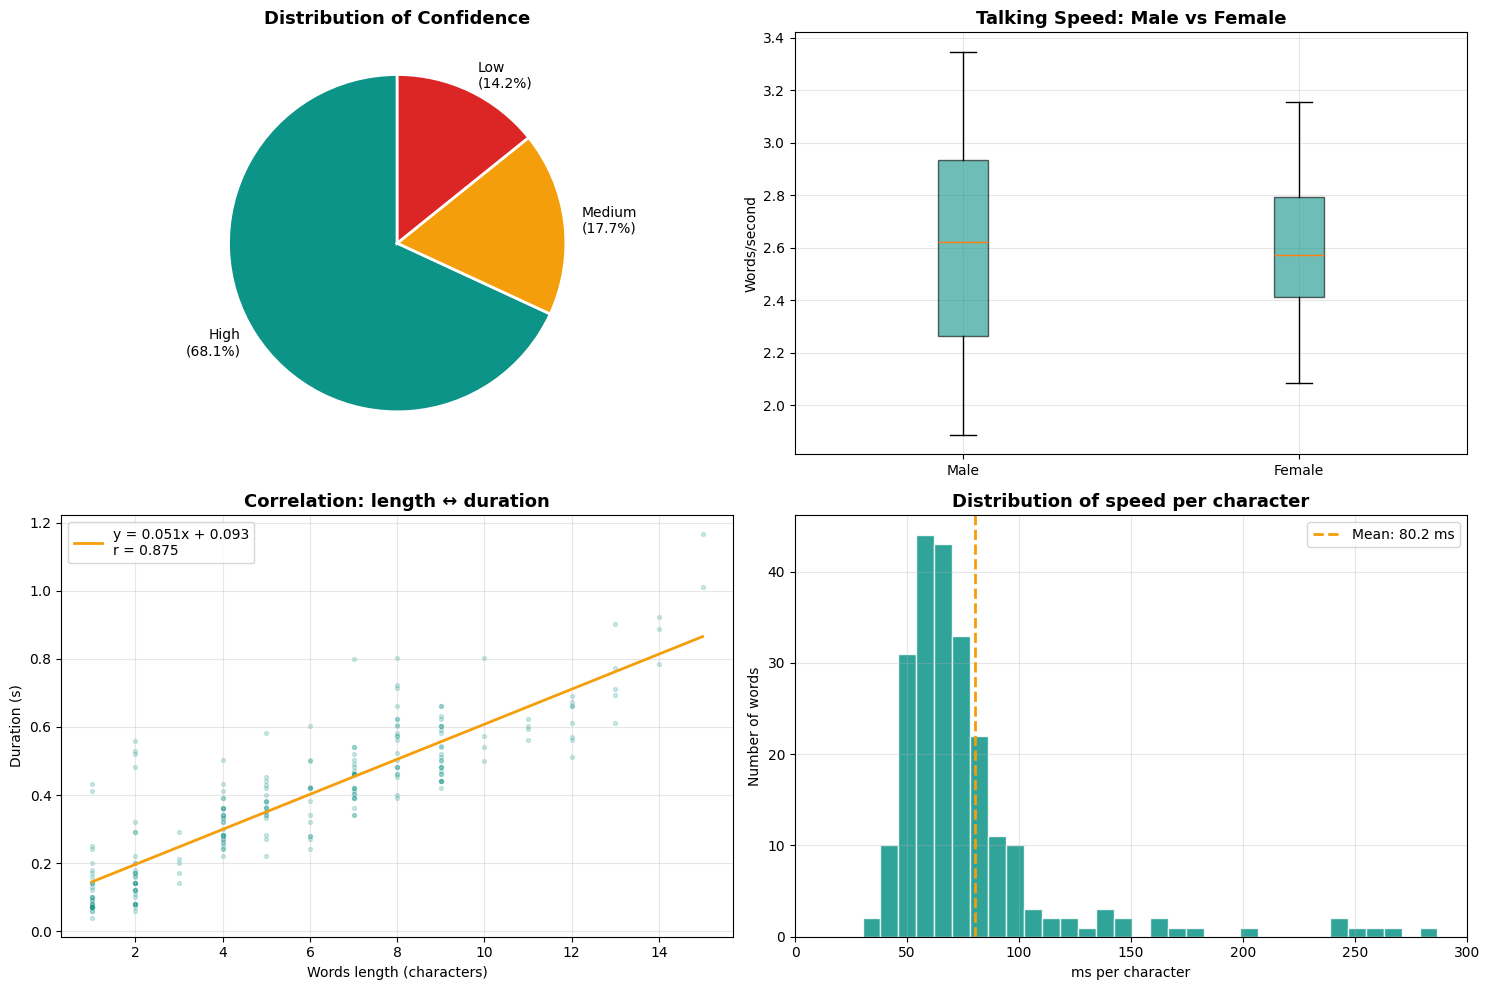


✓ Photo saved as png: dataset_analysis.png


In [103]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ── Get all data from the entire dataset ──────────────────────────────────────
all_segments = []   # all segments
by_speakers = {} # for comparison of m vs z

for r in results:
    for seg in r["segments"]:
        dur = seg["end"] - seg["start"]
        all_segments.append({
            "word": seg["text"],
            "duration": dur,
            "confidence": seg["conf"],
            "char_length": len(seg["text"]),
            "speaker": r["speaker"],
            "gender": "m" if r["speaker"].startswith("m") else "z",
        })
    
    # Speech speed per recording
    if r["segments"]:
        recording_duration = r["segments"][-1]["end"] - r["segments"][0]["start"]
        word_count = len(r["segments"])
        wps = word_count / recording_duration if recording_duration > 0 else 0
        
        gender = "m" if r["speaker"].startswith("m") else "z"
        by_speakers.setdefault(gender, []).append(wps)

print(f"Number of segmented words: {len(all_segments)}")
print(f"From a total of {len(results)} recordings")
print(f"\n{'='*60}")

# ── 1. success rate ─────────────────────────────────────────
confs = [s["confidence"] for s in all_segments]
visoka  = sum(1 for c in confs if c > -1.0)
srednja = sum(1 for c in confs if -2.0 < c <= -1.0)
niska   = sum(1 for c in confs if c <= -2.0)
n = len(confs)

print(f"\n1. Success Rate (based on confidence)")
print(f"   High  (conf > -1.0):   {visoka:5d}  ({visoka/n*100:.1f}%)")
print(f"   Mid (-2.0 to -1.0):  {srednja:5d}  ({srednja/n*100:.1f}%)")
print(f"   Low   (conf < -2.0):   {niska:5d}  ({niska/n*100:.1f}%)")
print(f"   Average confidence:      {np.mean(confs):.3f}")

# ── 2. Talking Speed Male vs Female ─────────────────────────────────────
print(f"\n2. TALKING SPEED (words/second)")
for gender in ["m", "z"]:
    if gender in by_speakers:
        wps_arr = by_speakers[gender]
        oznaka = "Male" if gender == "m" else "Female"
        print(f"   {oznaka:8s}: mean={np.mean(wps_arr):.2f}  "
              f"median={np.median(wps_arr):.2f}  "
              f"std={np.std(wps_arr):.2f}")

# ── 3. Correlation between word length and duration ─────────────────────────────
lengths = np.array([s["char_length"] for s in all_segments])
durations = np.array([s["duration"] for s in all_segments])

# Pearson correlation coefficient
r_koef = np.corrcoef(lengths, durations)[0, 1]

print(f"\n3. CORRELATION: word length ↔ duration")
print(f"   Pearson r = {r_koef:.3f}")
print(f"   (>0.7 = strong positive correlation = segmentation makes sense)")

# ── 4. Average duration per character ───────────────────────────────────────
ms_per_char = np.array([s["duration"]/s["char_length"]*1000 
                         for s in all_segments if s["char_length"] > 0])
print(f"\n4. AVERAGE DURATION PER CHARACTER")
print(f"   Entire dataset: {np.mean(ms_per_char):.1f} ms/character")

for gender in ["m", "z"]:
    gender_ms = [s["duration"]/s["char_length"]*1000 
                  for s in all_segments 
                  if s["gender"] == gender and s["char_length"] > 0]
    if gender_ms:
        oznaka = "Male" if gender == "m" else "Female"
        print(f"   {oznaka:8s}:    {np.mean(gender_ms):.1f} ms/character")

# ── Graphs ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor("white")

# Graph 1: Confidence pie chart
axes[0,0].pie([visoka, srednja, niska],
              labels=[f"High\n({visoka/n*100:.1f}%)",
                      f"Medium\n({srednja/n*100:.1f}%)",
                      f"Low\n({niska/n*100:.1f}%)"],
              colors=["#0D9488", "#F59E0B", "#DC2626"],
              startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0,0].set_title("Distribution of Confidence", fontsize=13, fontweight="bold")

# Graph 2: talking speed male vs female
if "m" in by_speakers and "z" in by_speakers:
    axes[0,1].boxplot([by_speakers["m"], by_speakers["z"]],
                       labels=["Male", "Female"],
                       patch_artist=True,
                       boxprops=dict(facecolor="#0D9488", alpha=0.6))
    axes[0,1].set_ylabel("Words/second")
    axes[0,1].set_title("Talking Speed: Male vs Female", fontsize=13, fontweight="bold")
    axes[0,1].grid(True, alpha=0.3)

# Graph 3: scatter length vs duration
# Sample max 2000 points so it's readable
idx = np.random.choice(len(lengths), size=min(2000, len(lengths)), replace=False)
axes[1,0].scatter(lengths[idx], durations[idx], alpha=0.2, s=8, color="#0D9488")
# Regression line
z = np.polyfit(lengths, durations, 1)
x_line = np.linspace(lengths.min(), lengths.max(), 100)
axes[1,0].plot(x_line, z[0]*x_line + z[1], color="#F59E0B", linewidth=2,
               label=f"y = {z[0]:.3f}x + {z[1]:.3f}\nr = {r_koef:.3f}")
axes[1,0].set_xlabel("Words length (characters)")
axes[1,0].set_ylabel("Duration (s)")
axes[1,0].set_title("Correlation: length ↔ duration", fontsize=13, fontweight="bold")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Graph 4: Histogram ms per character
axes[1,1].hist(ms_per_char, bins=50, color="#0D9488",
               edgecolor="white", alpha=0.85)
axes[1,1].axvline(np.mean(ms_per_char), color="#F59E0B", linewidth=2,
                   linestyle="--", label=f"Mean: {np.mean(ms_per_char):.1f} ms")
axes[1,1].set_xlabel("ms per character")
axes[1,1].set_ylabel("Number of words")
axes[1,1].set_title("Distribution of speed per character", fontsize=13, fontweight="bold")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_xlim(0, 300)

plt.tight_layout()
plt.savefig("dataset_analysis.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("\n✓ Photo saved as png: dataset_analysis.png")